Total folders: 8


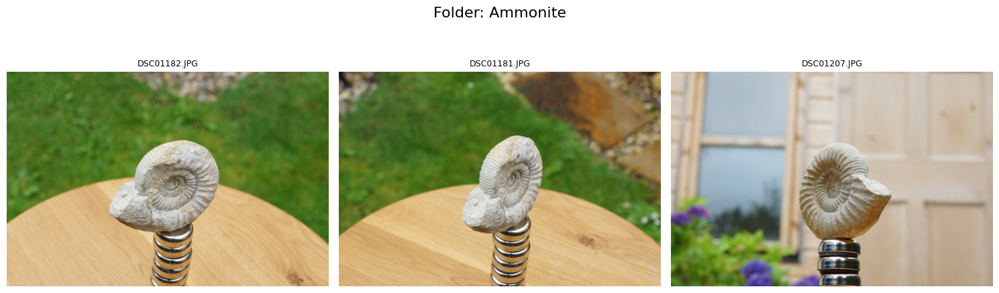

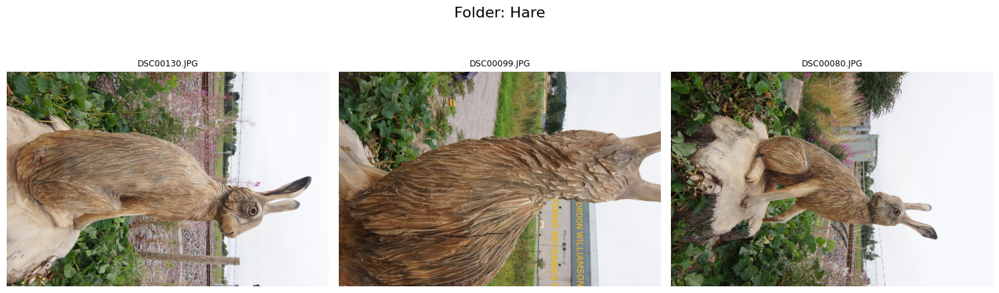

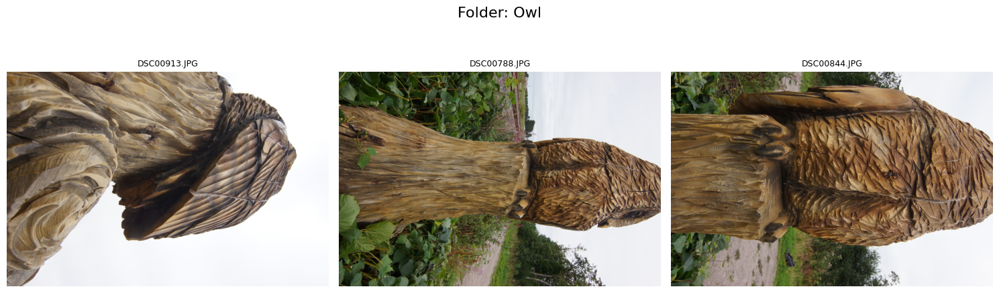

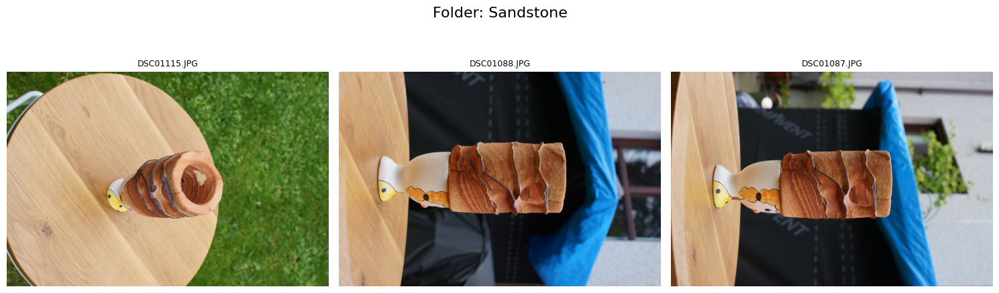

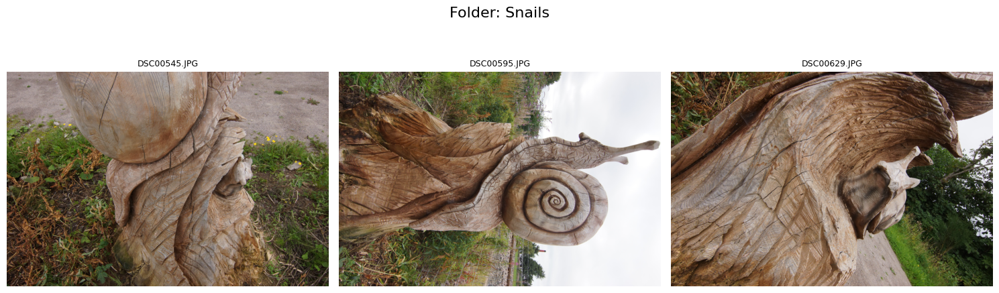

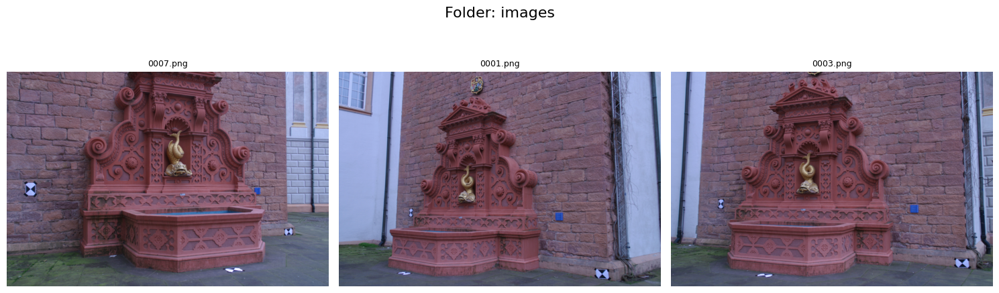

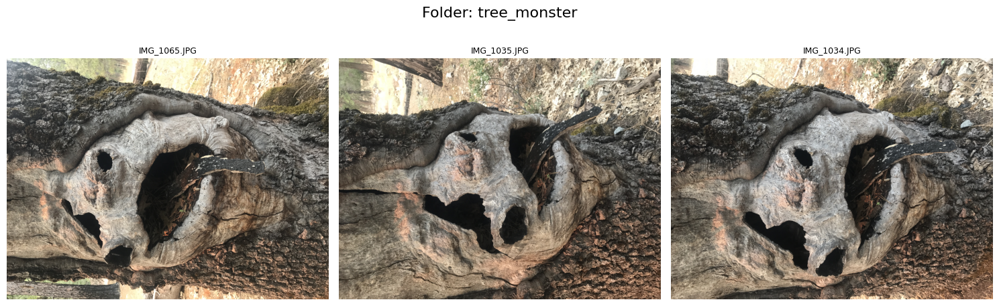

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/kaggle/input/3d-object-reconstruction-from-images"

folders = sorted([
    f for f in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, f))
])

print("Total folders:", len(folders))

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
    ]

    if len(image_files) == 0:
        continue

    selected_images = random.sample(image_files, min(3, len(image_files)))

    fig, axes = plt.subplots(1, len(selected_images), figsize=(15, 5))

    if len(selected_images) == 1:
        axes = [axes]

    for ax, img_name in zip(axes, selected_images):
        img_path = os.path.join(folder_path, img_name)

        img = Image.open(img_path)

        ax.imshow(img)
        ax.set_title(img_name, fontsize=9)
        ax.axis("off")

    plt.suptitle(f"Folder: {folder}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [2]:
import os, random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_PATH = "/kaggle/input/3d-object-reconstruction-from-images"
IMG_SIZE = 128
PATCH_SIZE = 16
NUM_PATCHES_SIDE = IMG_SIZE // PATCH_SIZE
NUM_PATCHES = NUM_PATCHES_SIDE ** 2
EMBED_DIM = 256
NUM_HEADS = 4
NUM_LAYERS = 6
NUM_REGISTERS = 16
FRAMES_PER_SAMPLE = 4
BATCH_SIZE = 2
EPOCHS = 10
LR = 2e-4
U = PATCH_SIZE
DEPTH_HEAD_OUT_CH = 2 * U * U


class MultiViewDataset(Dataset):
    def __init__(self, root, frames_per_sample=FRAMES_PER_SAMPLE, img_size=IMG_SIZE):
        self.frames_per_sample = frames_per_sample
        self.transform = T.Compose([T.Resize((img_size, img_size)), T.ToTensor()])
        self.samples = []
        folders = sorted([os.path.join(root, f) for f in os.listdir(root) if os.path.isdir(os.path.join(root, f))])
        for folder in folders:
            imgs = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))]
            if len(imgs) >= 2:
                self.samples.append((folder, imgs))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        folder, imgs = self.samples[idx]
        n = min(self.frames_per_sample, len(imgs))
        chosen = random.sample(imgs, n)
        while len(chosen) < self.frames_per_sample:
            chosen.append(random.choice(imgs))
        frames = []
        for im_name in chosen:
            img = Image.open(os.path.join(folder, im_name)).convert("RGB")
            frames.append(self.transform(img))
        return torch.stack(frames, dim=0)


class PatchEmbed(nn.Module):
    def __init__(self, embed_dim, patch_size):
        super().__init__()
        self.proj = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerLayer(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 4), nn.GELU(), nn.Linear(dim * 4, dim))

    def forward(self, x):
        h = self.norm1(x)
        a, _ = self.attn(h, h, h)
        x = x + a
        x = x + self.mlp(self.norm2(x))
        return x


class VGGTOmegaLite(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = PatchEmbed(EMBED_DIM, PATCH_SIZE)
        self.pos_embed = nn.Parameter(torch.zeros(1, NUM_PATCHES, EMBED_DIM))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.camera_token = nn.Parameter(torch.zeros(1, 1, EMBED_DIM))
        self.register_tokens = nn.Parameter(torch.zeros(1, NUM_REGISTERS, EMBED_DIM))
        nn.init.trunc_normal_(self.camera_token, std=0.02)
        nn.init.trunc_normal_(self.register_tokens, std=0.02)
        self.frame_layers = nn.ModuleList([TransformerLayer(EMBED_DIM, NUM_HEADS) for _ in range(NUM_LAYERS)])
        self.register_layers = nn.ModuleList([TransformerLayer(EMBED_DIM, NUM_HEADS) for _ in range(NUM_LAYERS)])
        self.depth_head = nn.Linear(EMBED_DIM, DEPTH_HEAD_OUT_CH)
        self.camera_head = nn.Sequential(nn.Linear(EMBED_DIM * 2, EMBED_DIM), nn.GELU(), nn.Linear(EMBED_DIM, 9))

    def forward(self, frames):
        B, N, C, H, W = frames.shape
        x = frames.view(B * N, C, H, W)
        patches = self.patch_embed(x) + self.pos_embed
        cam = self.camera_token.expand(B * N, -1, -1)
        regs = self.register_tokens.expand(B * N, -1, -1)
        tokens = torch.cat([patches, cam, regs], dim=1)
        T_tot = tokens.shape[1]
        tokens = tokens.view(B, N, T_tot, EMBED_DIM)

        for i in range(NUM_LAYERS):
            t2 = tokens.view(B * N, T_tot, EMBED_DIM)
            t2 = self.frame_layers[i](t2)
            tokens = t2.view(B, N, T_tot, EMBED_DIM)

            reg_slice = tokens[:, :, NUM_PATCHES + 1:, :]
            reg_slice = reg_slice.reshape(B, N * NUM_REGISTERS, EMBED_DIM)
            reg_slice = self.register_layers[i](reg_slice)
            reg_slice = reg_slice.view(B, N, NUM_REGISTERS, EMBED_DIM)
            tokens = torch.cat([tokens[:, :, :NUM_PATCHES + 1, :], reg_slice], dim=2)

        patch_tokens = tokens[:, :, :NUM_PATCHES, :]
        cam_tokens = tokens[:, :, NUM_PATCHES, :]
        reg_tokens = tokens[:, :, NUM_PATCHES + 1:, :]

        patch_tokens_flat = patch_tokens.reshape(B * N, NUM_PATCHES, EMBED_DIM)
        depth_out = self.depth_head(patch_tokens_flat)
        depth_out = depth_out.transpose(1, 2).view(B * N, DEPTH_HEAD_OUT_CH, NUM_PATCHES_SIDE, NUM_PATCHES_SIDE)
        depth_out = F.pixel_shuffle(depth_out, U)
        depth = F.softplus(depth_out[:, 0:1]) + 1e-3
        conf = torch.sigmoid(depth_out[:, 1:2])
        depth = depth.view(B, N, 1, H, W)
        conf = conf.view(B, N, 1, H, W)

        reg_mean = reg_tokens.mean(dim=2)
        cam_input = torch.cat([cam_tokens, reg_mean], dim=-1)
        cam_out = self.camera_head(cam_input)
        quat = F.normalize(cam_out[..., :4], dim=-1)
        trans = cam_out[..., 4:7]
        fov = torch.sigmoid(cam_out[..., 7:9]) * (math.radians(150) - math.radians(20)) + math.radians(20)

        return depth, conf, quat, trans, fov, patch_tokens


def quat_to_matrix(q):
    q = F.normalize(q, dim=-1)
    w, x, y, z = q.unbind(-1)
    R = torch.stack([
        1 - 2 * (y ** 2 + z ** 2), 2 * (x * y - z * w), 2 * (x * z + y * w),
        2 * (x * y + z * w), 1 - 2 * (x ** 2 + z ** 2), 2 * (y * z - x * w),
        2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x ** 2 + y ** 2)
    ], dim=-1).view(*q.shape[:-1], 3, 3)
    return R


def fov_to_intrinsics(fov, H, W):
    fx = (W / 2.0) / torch.tan(fov[..., 0] / 2.0)
    fy = (H / 2.0) / torch.tan(fov[..., 1] / 2.0)
    cx = torch.full_like(fx, W / 2.0)
    cy = torch.full_like(fy, H / 2.0)
    return fx, fy, cx, cy


def warp_frame(ti, si, depth, quat, trans, fov, images, H, W):
    B = depth.shape[0]
    depth_t = depth[:, ti, 0]
    R_t = quat_to_matrix(quat[:, ti])
    t_t = trans[:, ti]
    R_s = quat_to_matrix(quat[:, si])
    t_s = trans[:, si]
    R_rel = torch.bmm(R_s, R_t.transpose(1, 2))
    t_rel = t_s - torch.bmm(R_rel, t_t.unsqueeze(-1)).squeeze(-1)

    fx_t, fy_t, cx_t, cy_t = fov_to_intrinsics(fov[:, ti], H, W)
    fx_s, fy_s, cx_s, cy_s = fov_to_intrinsics(fov[:, si], H, W)

    v_range = torch.arange(H, device=depth.device, dtype=torch.float32)
    u_range = torch.arange(W, device=depth.device, dtype=torch.float32)
    vv, uu = torch.meshgrid(v_range, u_range, indexing="ij")
    uu = uu.unsqueeze(0).expand(B, -1, -1)
    vv = vv.unsqueeze(0).expand(B, -1, -1)

    X = (uu - cx_t.view(B, 1, 1)) / fx_t.view(B, 1, 1) * depth_t
    Y = (vv - cy_t.view(B, 1, 1)) / fy_t.view(B, 1, 1) * depth_t
    Z = depth_t

    pts = torch.stack([X, Y, Z], dim=-1)
    pts_s = torch.einsum("bij,bhwj->bhwi", R_rel, pts) + t_rel.view(B, 1, 1, 3)
    Xs, Ys, Zs = pts_s[..., 0], pts_s[..., 1], pts_s[..., 2].clamp(min=1e-3)

    u_s = fx_s.view(B, 1, 1) * Xs / Zs + cx_s.view(B, 1, 1)
    v_s = fy_s.view(B, 1, 1) * Ys / Zs + cy_s.view(B, 1, 1)

    grid_x = 2 * u_s / (W - 1) - 1
    grid_y = 2 * v_s / (H - 1) - 1
    grid = torch.stack([grid_x, grid_y], dim=-1)

    src_img = images[:, si]
    warped = F.grid_sample(src_img, grid, align_corners=True, padding_mode="zeros")
    valid = ((grid_x >= -1) & (grid_x <= 1) & (grid_y >= -1) & (grid_y <= 1) & (pts_s[..., 2] > 0)).float().unsqueeze(1)
    return warped, valid, grid


def ssim(x, y):
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    mu_x = F.avg_pool2d(x, 3, 1, 1)
    mu_y = F.avg_pool2d(y, 3, 1, 1)
    sigma_x = F.avg_pool2d(x * x, 3, 1, 1) - mu_x ** 2
    sigma_y = F.avg_pool2d(y * y, 3, 1, 1) - mu_y ** 2
    sigma_xy = F.avg_pool2d(x * y, 3, 1, 1) - mu_x * mu_y
    ssim_n = (2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)
    ssim_d = (mu_x ** 2 + mu_y ** 2 + C1) * (sigma_x + sigma_y + C2)
    return torch.clamp((1 - ssim_n / ssim_d) / 2, 0, 1)


def photometric_loss(warped, target, mask):
    l1 = (warped - target).abs().mean(1, keepdim=True)
    s = ssim(warped, target).mean(1, keepdim=True)
    loss = 0.15 * l1 + 0.85 * s
    loss = (loss * mask).sum() / (mask.sum() + 1e-6)
    return loss


def smoothness_loss(depth, image):
    depth = depth / (depth.mean([2, 3], keepdim=True) + 1e-6)
    dx_d = torch.abs(depth[:, :, :, :-1] - depth[:, :, :, 1:])
    dy_d = torch.abs(depth[:, :, :-1, :] - depth[:, :, 1:, :])
    dx_i = torch.mean(torch.abs(image[:, :, :, :-1] - image[:, :, :, 1:]), 1, keepdim=True)
    dy_i = torch.mean(torch.abs(image[:, :, :-1, :] - image[:, :, 1:, :]), 1, keepdim=True)
    dx_d = dx_d * torch.exp(-dx_i)
    dy_d = dy_d * torch.exp(-dy_i)
    return dx_d.mean() + dy_d.mean()


def matching_loss(target_feat, source_feat, positive_idx, valid):
    target_n = F.normalize(target_feat, dim=-1)
    source_n = F.normalize(source_feat, dim=-1)
    sim = torch.bmm(target_n, source_n.transpose(1, 2)) / 0.07
    B, P, _ = sim.shape
    sim = sim.reshape(B * P, P)
    positive_idx = positive_idx.reshape(B * P)
    valid = valid.reshape(B * P)
    loss_all = F.cross_entropy(sim, positive_idx, reduction="none")
    loss = (loss_all * valid).sum() / (valid.sum() + 1e-6)
    with torch.no_grad():
        pred = sim.argmax(dim=-1)
        acc = ((pred == positive_idx).float() * valid).sum() / (valid.sum() + 1e-6)
    return loss, acc


def baseline_reg_loss(trans, min_baseline=0.1):
    ref = trans[:, 0:1, :]
    dist = (trans[:, 1:, :] - ref).norm(dim=-1)
    loss = F.relu(min_baseline - dist).mean()
    return loss


def train_one_epoch(model, loader, optimizer):
    model.train()
    running = {"total": 0, "photo": 0, "smooth": 0, "match": 0, "camera_reg": 0, "match_acc": 0}
    steps = 0
    pbar = tqdm(loader, desc="train", leave=False)
    for frames in pbar:
        frames = frames.to(device)
        B, N, C, H, W = frames.shape
        depth, conf, quat, trans, fov, patch_tokens = model(frames)

        photo_total = 0.0
        smooth_total = 0.0
        match_total = 0.0
        match_acc_total = 0.0
        pair_count = 0

        for j in range(1, N):
            warped, mask, grid = warp_frame(0, j, depth, quat, trans, fov, frames, H, W)
            target_img = frames[:, 0]
            p_loss = photometric_loss(warped, target_img, mask)
            photo_total = photo_total + p_loss
            s_loss = smoothness_loss(depth[:, 0], frames[:, 0])
            smooth_total = smooth_total + s_loss

            mask_patch = F.avg_pool2d(mask, PATCH_SIZE, PATCH_SIZE)
            valid_patch = (mask_patch.squeeze(1) > 0.5).float().reshape(B, -1)
            grid_x = grid[..., 0].unsqueeze(1)
            grid_y = grid[..., 1].unsqueeze(1)
            gx_pool = F.avg_pool2d(grid_x, PATCH_SIZE, PATCH_SIZE)
            gy_pool = F.avg_pool2d(grid_y, PATCH_SIZE, PATCH_SIZE)
            u_pix = (gx_pool + 1) * (W - 1) / 2.0
            v_pix = (gy_pool + 1) * (H - 1) / 2.0
            col = torch.clamp((u_pix / PATCH_SIZE).round(), 0, NUM_PATCHES_SIDE - 1).long()
            row = torch.clamp((v_pix / PATCH_SIZE).round(), 0, NUM_PATCHES_SIDE - 1).long()
            pos_idx = (row * NUM_PATCHES_SIDE + col).reshape(B, -1)

            m_loss, m_acc = matching_loss(patch_tokens[:, 0], patch_tokens[:, j], pos_idx, valid_patch)
            match_total = match_total + m_loss
            match_acc_total = match_acc_total + m_acc
            pair_count += 1

        photo_total = photo_total / pair_count
        smooth_total = smooth_total / pair_count
        match_total = match_total / pair_count
        match_acc_total = match_acc_total / pair_count
        c_loss = baseline_reg_loss(trans)

        total_loss = photo_total + 0.1 * smooth_total + 0.3 * match_total + 0.05 * c_loss

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running["total"] += total_loss.item()
        running["photo"] += photo_total.item()
        running["smooth"] += smooth_total.item()
        running["match"] += match_total.item()
        running["camera_reg"] += c_loss.item()
        running["match_acc"] += match_acc_total.item()
        steps += 1
        pbar.set_postfix({k: round(v / steps, 4) for k, v in running.items()})

    return {k: v / steps for k, v in running.items()}


def run_validation(model, loader):
    model.eval()
    running = {"total": 0, "photo": 0, "smooth": 0, "match": 0, "camera_reg": 0, "match_acc": 0}
    steps = 0
    with torch.no_grad():
        for frames in loader:
            frames = frames.to(device)
            B, N, C, H, W = frames.shape
            depth, conf, quat, trans, fov, patch_tokens = model(frames)

            photo_total = 0.0
            smooth_total = 0.0
            match_total = 0.0
            match_acc_total = 0.0
            pair_count = 0

            for j in range(1, N):
                warped, mask, grid = warp_frame(0, j, depth, quat, trans, fov, frames, H, W)
                target_img = frames[:, 0]
                p_loss = photometric_loss(warped, target_img, mask)
                photo_total = photo_total + p_loss
                s_loss = smoothness_loss(depth[:, 0], frames[:, 0])
                smooth_total = smooth_total + s_loss

                mask_patch = F.avg_pool2d(mask, PATCH_SIZE, PATCH_SIZE)
                valid_patch = (mask_patch.squeeze(1) > 0.5).float().reshape(B, -1)
                grid_x = grid[..., 0].unsqueeze(1)
                grid_y = grid[..., 1].unsqueeze(1)
                gx_pool = F.avg_pool2d(grid_x, PATCH_SIZE, PATCH_SIZE)
                gy_pool = F.avg_pool2d(grid_y, PATCH_SIZE, PATCH_SIZE)
                u_pix = (gx_pool + 1) * (W - 1) / 2.0
                v_pix = (gy_pool + 1) * (H - 1) / 2.0
                col = torch.clamp((u_pix / PATCH_SIZE).round(), 0, NUM_PATCHES_SIDE - 1).long()
                row = torch.clamp((v_pix / PATCH_SIZE).round(), 0, NUM_PATCHES_SIDE - 1).long()
                pos_idx = (row * NUM_PATCHES_SIDE + col).reshape(B, -1)

                m_loss, m_acc = matching_loss(patch_tokens[:, 0], patch_tokens[:, j], pos_idx, valid_patch)
                match_total = match_total + m_loss
                match_acc_total = match_acc_total + m_acc
                pair_count += 1

            photo_total = photo_total / pair_count
            smooth_total = smooth_total / pair_count
            match_total = match_total / pair_count
            match_acc_total = match_acc_total / pair_count
            c_loss = baseline_reg_loss(trans)
            total_loss = photo_total + 0.1 * smooth_total + 0.3 * match_total + 0.05 * c_loss

            running["total"] += total_loss.item()
            running["photo"] += photo_total.item()
            running["smooth"] += smooth_total.item()
            running["match"] += match_total.item()
            running["camera_reg"] += c_loss.item()
            running["match_acc"] += match_acc_total.item()
            steps += 1

    if steps == 0:
        return {k: 0.0 for k in running}
    return {k: v / steps for k, v in running.items()}


full_dataset = MultiViewDataset(DATASET_PATH)
n_total = len(full_dataset)
n_val = max(1, int(0.1 * n_total))
n_train = n_total - n_val
train_set, val_set = torch.utils.data.random_split(full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=False, pin_memory=True)

print(f"Total scenes: {n_total} | Train: {n_train} | Val: {n_val}")

model = VGGTOmegaLite().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params/1e6:.2f}M")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {
    "train_total": [], "train_photo": [], "train_smooth": [], "train_match": [], "train_camera_reg": [], "train_match_acc": [],
    "val_total": [], "val_photo": [], "val_smooth": [], "val_match": [], "val_camera_reg": [], "val_match_acc": [],
}

for epoch in range(EPOCHS):
    train_stats = train_one_epoch(model, train_loader, optimizer)
    val_stats = run_validation(model, val_loader)
    scheduler.step()
    for k in train_stats:
        history[f"train_{k}"].append(train_stats[k])
        history[f"val_{k}"].append(val_stats[k])
    print(f"Epoch {epoch+1}/{EPOCHS} | train_total {train_stats['total']:.4f} | val_total {val_stats['total']:.4f} | "
          f"train_photo {train_stats['photo']:.4f} | val_photo {val_stats['photo']:.4f} | "
          f"train_match_acc {train_stats['match_acc']:.4f} | val_match_acc {val_stats['match_acc']:.4f}")

print("\nFinal Metrics Summary")
print(f"Final Train Total Loss     : {history['train_total'][-1]:.4f}")
print(f"Final Val   Total Loss     : {history['val_total'][-1]:.4f}")
print(f"Final Train Photometric    : {history['train_photo'][-1]:.4f}")
print(f"Final Val   Photometric    : {history['val_photo'][-1]:.4f}")
print(f"Final Train Depth Smooth   : {history['train_smooth'][-1]:.4f}")
print(f"Final Val   Depth Smooth   : {history['val_smooth'][-1]:.4f}")
print(f"Final Train Match Loss     : {history['train_match'][-1]:.4f}")
print(f"Final Val   Match Loss     : {history['val_match'][-1]:.4f}")
print(f"Final Train Match Accuracy : {history['train_match_acc'][-1]*100:.2f}%")
print(f"Final Val   Match Accuracy : {history['val_match_acc'][-1]*100:.2f}%")
print(f"Final Camera Baseline Reg  : {history['val_camera_reg'][-1]:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metric_names = ["total", "photo", "smooth", "match", "camera_reg", "match_acc"]
for ax, name in zip(axes.flat, metric_names):
    ax.plot(history[f"train_{name}"], label="train", marker="o")
    ax.plot(history[f"val_{name}"], label="val", marker="s")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curves.png", dpi=150)
plt.show()

model.eval()
with torch.no_grad():
    frames = next(iter(val_loader)).to(device)
    B, N, C, H, W = frames.shape
    depth, conf, quat, trans, fov, patch_tokens = model(frames)

    n_show = min(4, N)
    fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 10))
    for k in range(n_show):
        img_k = frames[0, k].permute(1, 2, 0).cpu().numpy()
        depth_k = depth[0, k, 0].cpu().numpy()
        conf_k = conf[0, k, 0].cpu().numpy()
        axes[0, k].imshow(img_k)
        axes[0, k].set_title(f"Input Frame {k}")
        axes[0, k].axis("off")
        im1 = axes[1, k].imshow(depth_k, cmap="inferno")
        axes[1, k].set_title(f"Predicted Depth {k}")
        axes[1, k].axis("off")
        plt.colorbar(im1, ax=axes[1, k], fraction=0.046)
        im2 = axes[2, k].imshow(conf_k, cmap="viridis")
        axes[2, k].set_title(f"Confidence {k}")
        axes[2, k].axis("off")
        plt.colorbar(im2, ax=axes[2, k], fraction=0.046)
    plt.tight_layout()
    plt.savefig("/kaggle/working/depth_confidence_grid.png", dpi=150)
    plt.show()

    if N > 1:
        warped, mask, grid = warp_frame(0, 1, depth, quat, trans, fov, frames, H, W)
        fig, axes = plt.subplots(1, 4, figsize=(18, 5))
        axes[0].imshow(frames[0, 0].permute(1, 2, 0).cpu().numpy())
        axes[0].set_title("Target Frame (0)")
        axes[0].axis("off")
        axes[1].imshow(frames[0, 1].permute(1, 2, 0).cpu().numpy())
        axes[1].set_title("Source Frame (1)")
        axes[1].axis("off")
        axes[2].imshow(warped[0].permute(1, 2, 0).cpu().numpy())
        axes[2].set_title("Warped Source -> Target")
        axes[2].axis("off")
        axes[3].imshow(mask[0, 0].cpu().numpy(), cmap="gray")
        axes[3].set_title("Valid Reprojection Mask")
        axes[3].axis("off")
        plt.tight_layout()
        plt.savefig("/kaggle/working/warp_comparison.png", dpi=150)
        plt.show()

    fx, fy, cx, cy = fov_to_intrinsics(fov[:, 0], H, W)
    d0 = depth[0, 0, 0].cpu().numpy()
    img0 = frames[0, 0].permute(1, 2, 0).cpu().numpy()
    fig = plt.figure(figsize=(16, 6))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    step = 4
    us, vs = np.meshgrid(np.arange(0, W, step), np.arange(0, H, step))
    dsub = d0[vs, us]
    xs = (us - cx[0].item()) / fx[0].item() * dsub
    ys = (vs - cy[0].item()) / fy[0].item() * dsub
    zs = dsub
    colors = img0[vs, us].reshape(-1, 3)
    ax1.scatter(xs.flatten(), zs.flatten(), -ys.flatten(), c=colors, s=3)
    ax1.set_title("Reconstructed 3D Point Cloud")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Z (depth)")
    ax1.set_zlabel("Y")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    cam_positions = trans[0].cpu().numpy()
    ax2.scatter(cam_positions[:, 0], cam_positions[:, 2], cam_positions[:, 1], c="red", s=80, marker="^")
    ax2.plot(cam_positions[:, 0], cam_positions[:, 2], cam_positions[:, 1], c="blue", linestyle="--")
    for idx in range(cam_positions.shape[0]):
        ax2.text(cam_positions[idx, 0], cam_positions[idx, 2], cam_positions[idx, 1], f"cam{idx}")
    ax2.set_title("Predicted Camera Trajectory")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Z")
    ax2.set_zlabel("Y")
    plt.tight_layout()
    plt.savefig("/kaggle/working/pointcloud_and_trajectory.png", dpi=150)
    plt.show()

print("Training and evaluation complete. All plots saved to /kaggle/working/")

Total scenes: 7 | Train: 6 | Val: 1
Model parameters: 9.96M


Epoch 1/10 | train_total 1.6982 | val_total 1.7222 | train_photo 0.3641 | val_photo 0.4086 | train_match_acc 0.0330 | val_match_acc 0.0415


Epoch 2/10 | train_total 1.6792 | val_total 1.6646 | train_photo 0.3582 | val_photo 0.3655 | train_match_acc 0.0520 | val_match_acc 0.0699


Epoch 3/10 | train_total 1.6076 | val_total 1.5923 | train_photo 0.3186 | val_photo 0.3455 | train_match_acc 0.0889 | val_match_acc 0.0586


Epoch 4/10 | train_total 1.6029 | val_total 1.6000 | train_photo 0.3201 | val_photo 0.3372 | train_match_acc 0.1017 | val_match_acc 0.1042


...

Epoch 6/10 | train_total 1.5851 | val_total 1.6608 | train_photo 0.3289 | val_photo 0.3733 | train_match_acc 0.0883 | val_match_acc 0.0227


Epoch 7/10 | train_total 1.5925 | val_total 1.6456 | train_photo 0.3275 | val_photo 0.3715 | train_match_acc 0.0936 | val_match_acc 0.0474


Epoch 8/10 | train_total 1.6370 | val_total 1.6616 | train_photo 0.3521 | val_photo 0.3739 | train_match_acc 0.0495 | val_match_acc 0.0417


Epoch 9/10 | train_total 1.6098 | val_total 1.6230 | train_photo 0.3483 | val_photo 0.3556 | train_match_acc 0.0738 | val_match_acc 0.0573


Epoch 10/10 | train_total 1.5973 | val_total 1.6237 | train_photo 0.3343 | val_photo 0.3750 | train_match_acc 0.1051 | val_match_acc 0.0644

Final Metrics Summary
Final Train Total Loss     : 1.5973
Final Val   Total Loss     : 1.6237
Final Train Photometric    : 0.3343
Final Val   Photometric    : 0.3750
Final Train Depth Smooth   : 0.1666
Final Val   Depth Smooth   : 0.1698
Final Train Match Loss     : 4.1448
Final Val   Match Loss     : 4.0972
Final Train Match Accuracy : 10.51%
Final Val   Match Accuracy : 6.44%
Final Camera Baseline Reg  : 0.0516
Training and evaluation complete. All plots saved to /kaggle/working/


Total Images: 4


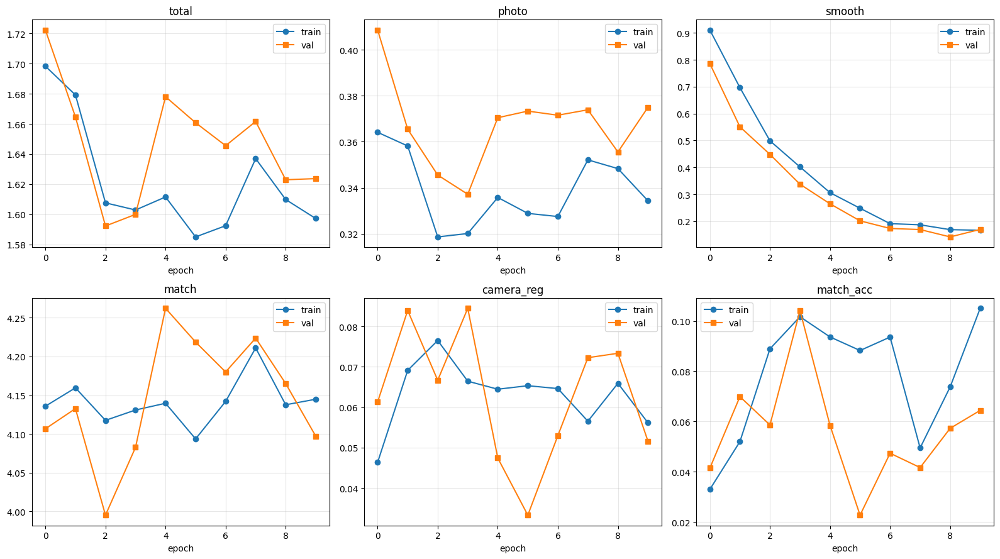

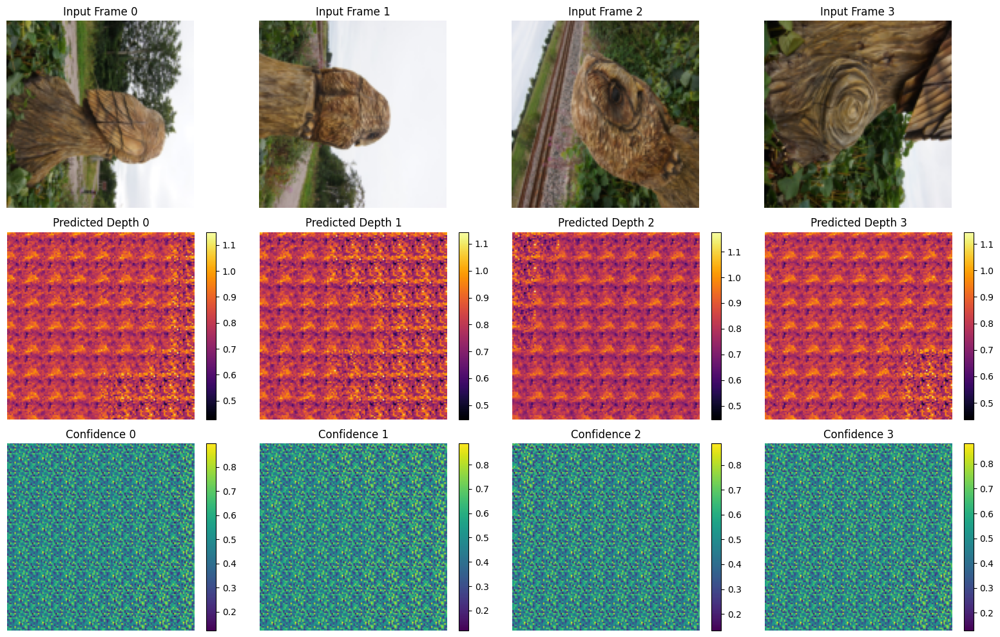

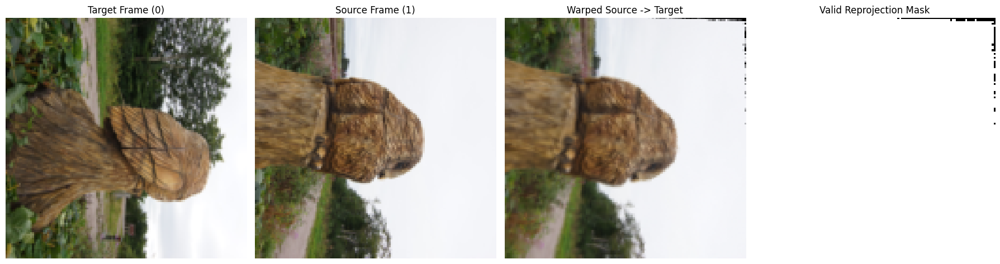

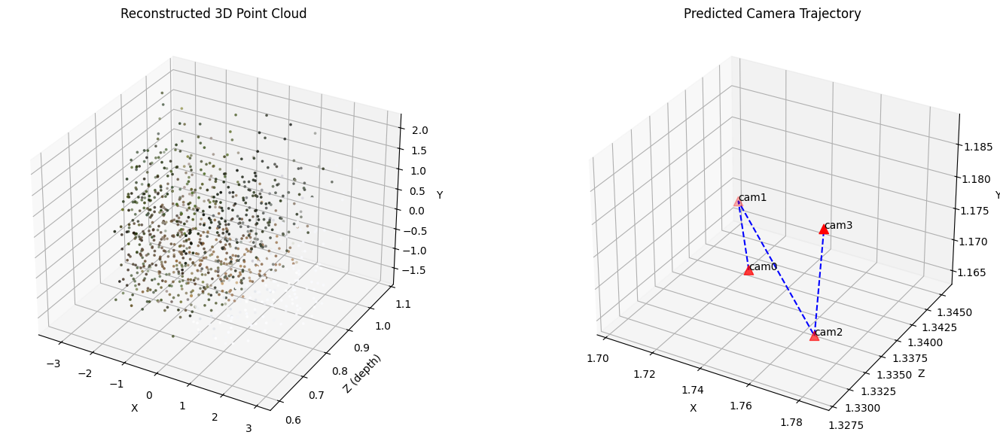

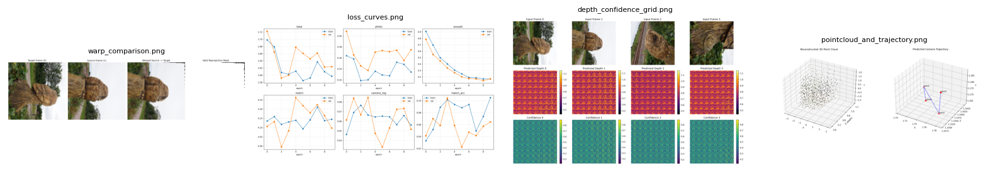

In [3]:
%matplotlib inline

import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

root_dir = "/kaggle/working/"
extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

# Get all image paths
image_paths = []
for root, _, files in os.walk(root_dir):
    for file in files:
        if file.lower().endswith(extensions):
            image_paths.append(os.path.join(root, file))

print(f"Total Images: {len(image_paths)}")

cols = 4
rows = math.ceil(len(image_paths) / cols)

plt.figure(figsize=(4 * cols, 4 * rows))

for i, img_path in enumerate(image_paths):
    img = mpimg.imread(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()